<a href="https://colab.research.google.com/github/steelpipe75/inhouse-ml-competition-MDXQ-alumni-Mar/blob/main/competition_files/playground/Colab/sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 内輪向け機械学習コンペ サンプル ノートブック

## コンペデータ取得

GitHubからリポジトリをcloneしてデータを持ってくる

In [1]:
REPO_URL = "https://github.com/steelpipe75/inhouse-ml-competition-MDXQ-alumni-Mar"
REPO_NAME = "inhouse-ml-competition-MDXQ-alumni-Mar"

In [2]:
!git clone {REPO_URL}

fatal: destination path 'inhouse-ml-competition-MDXQ-alumni-Mar' already exists and is not an empty directory.


## ライブラリをインポート

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [4]:
train_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/train.csv")

In [5]:
train_df

,id,temperature,sunshine_h,humidity,ice_sales
0,1,23.2,6.2,56.5,324
1,2,31.3,5.2,69.0,640
2,3,28.2,3.9,80.6,306
3,4,26.4,6.9,75.6,477
4,5,20.2,6.1,78.2,267
...,...,...,...,...,...
495,496,22.9,2.5,73.4,77
496,497,26.2,7.5,71.7,573
497,498,19.1,2.8,66.2,31
498,499,31.6,7.7,63.3,789


### 評価用データ読み込み

In [6]:
test_df = pd.read_csv(f"./{REPO_NAME}/competition_files/data/test.csv")

In [7]:
test_df

,id,temperature,sunshine_h,humidity
0,544,27.7,4.5,76.6
1,516,27.5,4.4,65.0
2,772,36.4,10.0,47.5
3,638,23.6,6.3,77.2
4,715,37.0,9.5,37.4
...,...,...,...,...
295,702,35.5,9.0,31.6
296,669,37.2,11.3,33.8
297,686,38.2,10.0,34.8
298,536,25.1,3.2,74.9


### サンプル投稿ファイル読み込み

In [8]:
submit = pd.read_csv(f"./{REPO_NAME}/competition_files/data/sample_submission.csv")

In [9]:
submit

,id,ice_sales
0,544,0
1,516,0
2,772,0
3,638,0
4,715,0
...,...,...
295,702,0
296,669,0
297,686,0
298,536,0


## 前処理

### 説明変数、目的変数に分割

In [10]:
features = ["temperature", "sunshine_h", "humidity"]

In [11]:
X = train_df[features]
y = train_df["ice_sales"]

In [12]:
X

,temperature,sunshine_h,humidity
0,23.2,6.2,56.5
1,31.3,5.2,69.0
2,28.2,3.9,80.6
3,26.4,6.9,75.6
4,20.2,6.1,78.2
...,...,...,...
495,22.9,2.5,73.4
496,26.2,7.5,71.7
497,19.1,2.8,66.2
498,31.6,7.7,63.3


In [13]:
y

,ice_sales
0,324
1,640
2,306
3,477
4,267
...,...
495,77
496,573
497,31
498,789


In [14]:
X_test = test_df[features]

In [15]:
X_test

,temperature,sunshine_h,humidity
0,27.7,4.5,76.6
1,27.5,4.4,65.0
2,36.4,10.0,47.5
3,23.6,6.3,77.2
4,37.0,9.5,37.4
...,...,...,...
295,35.5,9.0,31.6
296,37.2,11.3,33.8
297,38.2,10.0,34.8
298,25.1,3.2,74.9


### 訓練用データ、検証用データに分割

In [16]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [17]:
X_train

,temperature,sunshine_h,humidity
350,25.0,2.4,80.3
151,21.4,5.2,79.3
351,30.0,6.5,70.3
367,30.7,3.1,81.8
15,20.6,2.2,82.4
...,...,...,...
291,18.5,5.5,54.6
71,20.8,6.7,58.2
485,30.6,5.0,62.8
415,24.3,4.6,82.8


In [18]:
y_train

,ice_sales
350,102
151,229
351,628
367,413
15,0
...,...
291,231
71,309
485,557
415,252


In [19]:
X_eval

,temperature,sunshine_h,humidity
477,25.8,2.3,76.7
182,30.9,3.0,72.1
129,25.2,3.5,59.1
189,21.4,3.1,74.8
321,28.0,2.0,55.6
...,...,...,...
425,25.7,2.1,83.8
484,26.2,6.4,61.4
435,27.8,3.6,51.0
319,21.5,4.0,52.1


In [20]:
y_eval

,ice_sales
477,166
182,409
129,193
189,65
321,244
...,...
425,147
484,468
435,337
319,164


## モデルを訓練

In [21]:
model = LR()

In [22]:
model.fit(X_train, y_train)

LinearRegression()

## 訓練済みモデルによる予測（検証用データ）

In [23]:
y_pred_eval = model.predict(X_eval)

In [24]:
y_pred_eval

array([160.44349536, 395.12922185, 257.53161764,  72.13601194,
       247.28705289, 329.20493858, 372.69625111, 329.30884961,
       259.27668463, 318.63007829, 354.37289996, 316.57130401,
       187.09641544, 360.60475429, 562.32948315, 493.55063415,
       614.06687313, 468.4882858 , 271.44730307, 180.59977486,
       582.57629188, 333.28605958, 268.59382319, 279.20275412,
       514.86270143, 414.36824471, 299.09598814, 361.32440007,
       213.65358686, 146.91394792, 578.02577481, 482.7217762 ,
        80.6648995 , 293.70686923, 317.1568324 , 217.34767864,
       422.52820157, 264.027334  , 508.07625177, 546.09286629,
        -1.89722243, -33.27696832, 387.15496551, 540.49395113,
       417.33232652, 246.35614516, 206.23423392, 248.69339267,
       207.77790046, 499.78043963, 373.04135827, 638.24955292,
       612.50774006,   6.21149526, 236.70260042, 570.8328064 ,
       142.89365827, 162.12193133, 504.17058708, 261.21031756,
       268.05984204, 183.16719939, 266.07330673, 449.80

予測精度の可視化

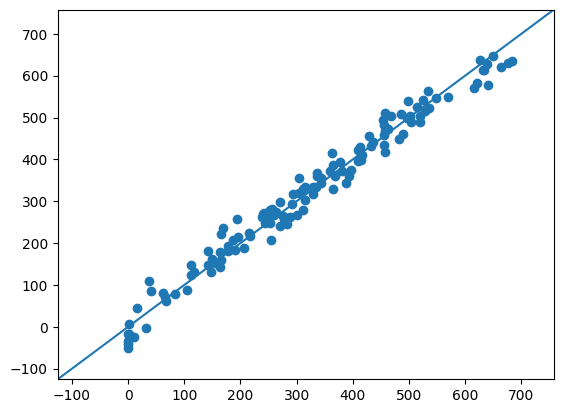

In [25]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [26]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [27]:
f"{rmse_eval=}"

'rmse_eval=np.float64(27.5908929495528)'

## 訓練済みモデルによる予測（評価用データ）

In [28]:
y_pred_test = model.predict(X_test)

In [29]:
y_pred_test

array([ 390.04387118,  394.24491122, 1145.74094828,  382.68357005,
       1145.15375378, 1154.25533229,  335.58080767,  329.4953638 ,
        239.61795873,  262.95565674,  322.21391499,  385.41221665,
       1146.17801737,  345.89668428,  285.26816406, 1245.30480533,
        384.61198066, 1371.11441167,  490.33696332,  397.09197239,
        311.76914619,  454.98751202, 1306.38118322,  300.47000095,
       1210.68691015,  333.29131778,  521.60812024,  310.24872293,
        543.80569454, 1198.46505255, 1183.31673997,  317.79553825,
        218.28438895, 1357.11755289, 1326.09192608,  347.34088431,
        544.72755445,  280.51833126,  238.87159101, 1342.66146759,
       1219.91974066,  171.46737384,  276.4677247 , 1104.95179382,
       1232.69127935,  538.21838452,  232.33569625, 1256.21139387,
       1197.57525031,  349.19388537,  493.52766306,  111.22058587,
       1087.55324265,  290.18034356, 1334.07464997, 1322.49791693,
        392.95524235, 1286.38438501,  482.84336135, 1288.09801

## 採点用投稿ファイル作成

In [30]:
submit["ice_sales"] = y_pred_test

In [31]:
submit

,id,ice_sales
0,544,390.043871
1,516,394.244911
2,772,1145.740948
3,638,382.683570
4,715,1145.153754
...,...,...
295,702,1065.602161
296,669,1292.126190
297,686,1227.825353
298,536,206.464952


In [32]:
submit.to_csv("submit.csv", index=False)